In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


Dataset loaded successfully!
Dataset shape: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PA

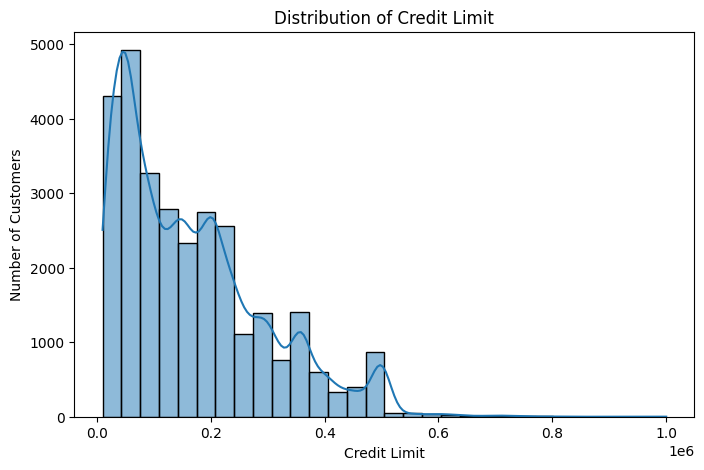

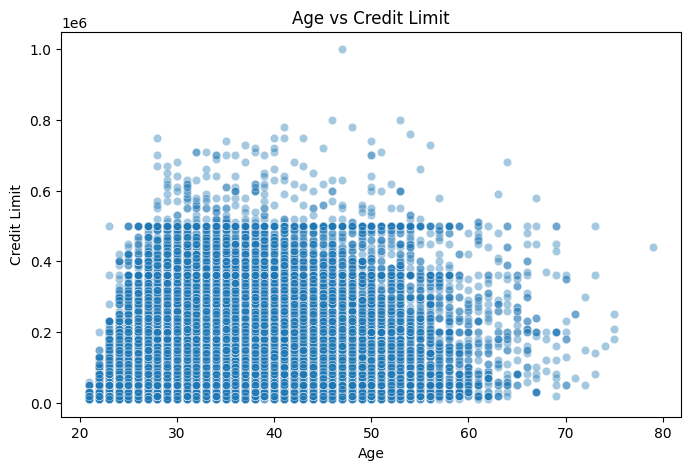

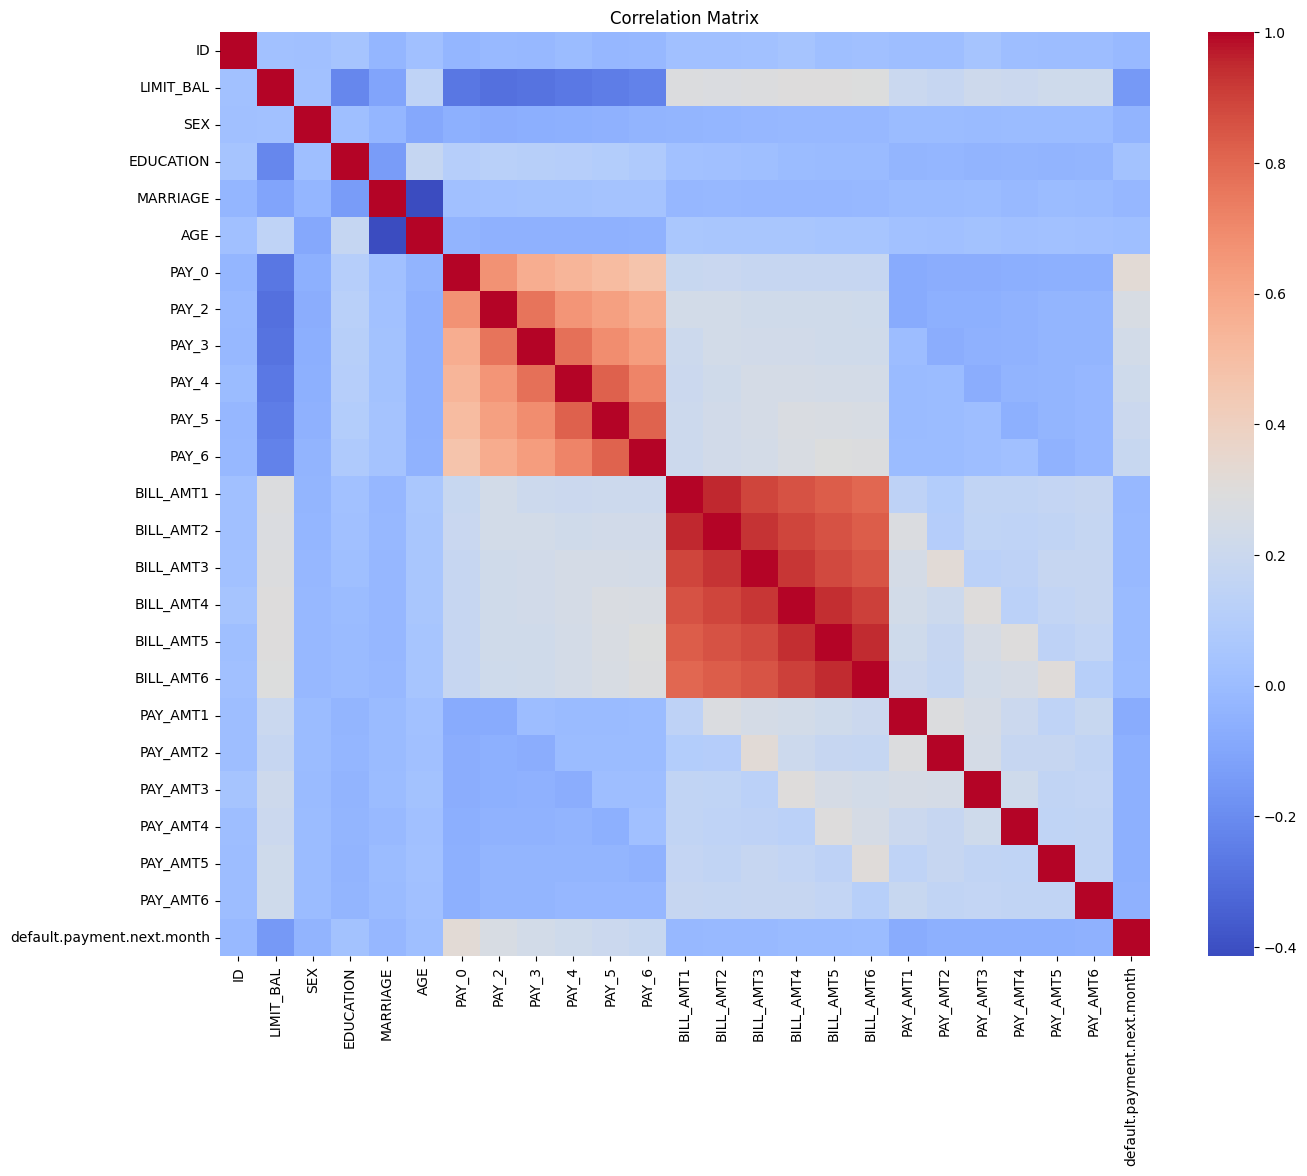


Features shape: (30000, 29)
Target shape: (30000,)

Training data: (24000, 29)
Testing data: (6000, 29)

Feature scaling completed!

================ LINEAR REGRESSION ================
MAE : 78882.31695828823
MSE : 10736673288.518265
RMSE: 103617.91972684197
R²  : 0.3626691916686987

================ RIDGE REGRESSION ================
MAE : 78882.42302188431
MSE : 10736634751.885427
RMSE: 103617.73377122966
R²  : 0.3626714792099788


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.951e+13, tolerance: 4.039e+10
  model = cd_fast.enet_coordinate_descent(



================ LASSO REGRESSION ================
MAE : 78882.29454050995
MSE : 10736668050.187607
RMSE: 103617.89444969245
R²  : 0.3626695026169249

================ ELASTIC NET =====================
MAE : 79111.08461588682
MSE : 10739861992.901484
RMSE: 103633.3054230226
R²  : 0.3624799096175946

================ MODEL COMPARISON =================
               Model           MAE           MSE           RMSE  R2 Score
0  Linear Regression  78882.316958  1.073667e+10  103617.919727  0.362669
1   Ridge Regression  78882.423022  1.073663e+10  103617.733771  0.362671
2   Lasso Regression  78882.294541  1.073667e+10  103617.894450  0.362670
3        Elastic Net  79111.084616  1.073986e+10  103633.305423  0.362480


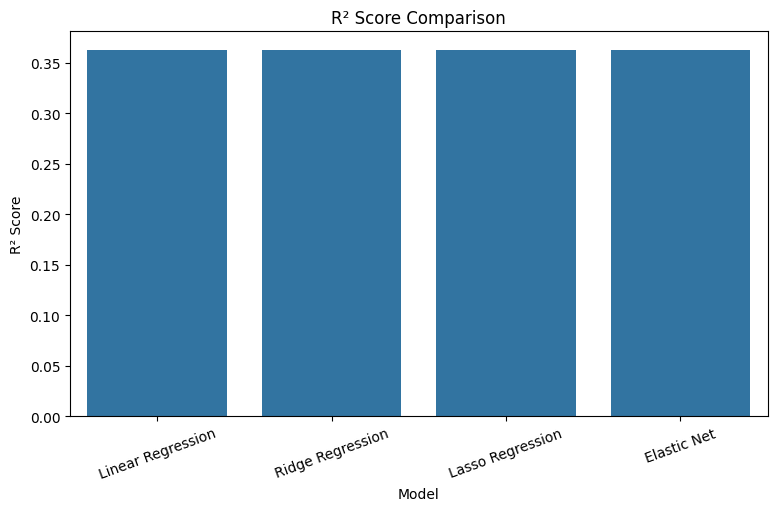

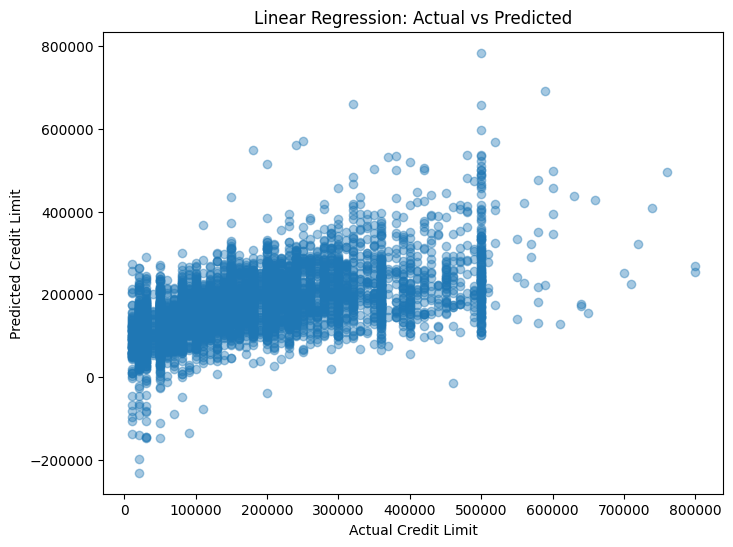


================ COEFFICIENT COMPARISON =============
                 Feature        Linear         Ridge         Lasso  \
0                    AGE  13124.812688  13124.389317  1.312470e+04   
1                    SEX   1856.711217   1856.631631  1.856590e+03   
2              EDUCATION -23397.712927 -23396.979861 -2.339757e+04   
3               MARRIAGE  -7911.741102  -7911.758646 -7.911674e+03   
4                  PAY_0 -15470.578631 -15469.182623 -2.022020e+04   
5                  PAY_2 -18732.842145 -18730.741051 -2.378271e+04   
6                  PAY_3 -10627.273686 -10627.769891 -1.565210e+04   
7                  PAY_4  -6373.608355  -6373.473392 -1.129890e+04   
8                  PAY_5  -2186.736366  -2187.436894 -6.963879e+03   
9                  PAY_6 -11300.938632 -11299.871597 -1.616029e+04   
10             BILL_AMT1  28883.295348  28860.429366  3.784497e+04   
11             BILL_AMT2  -9830.279161  -9805.355750 -1.162688e+03   
12             BILL_AMT3  -3537.811

In [ ]:
# LINEAR REGRESSION AND REGULARISATION PROJECT
# UCI CREDIT CARD DATASET

# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# -------------------- 2. LOAD DATASET ------------------------

df = pd.read_csv("UCI_Credit_Card.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# -------------------- 3. BASIC DATA INFORMATION -------------

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# -------------------- 4. REMOVE DUPLICATES -------------------

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


# ============================================================
#                     EXPLORATORY DATA ANALYSIS
# ============================================================

# -------------------- 5. TARGET DISTRIBUTION ----------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df["LIMIT_BAL"],
    bins=30,
    kde=True
)

plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()


# -------------------- 6. AGE VS CREDIT LIMIT ----------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="AGE",
    y="LIMIT_BAL",
    data=df,
    alpha=0.4
)

plt.title("Age vs Credit Limit")
plt.xlabel("Age")
plt.ylabel("Credit Limit")

plt.show()


# -------------------- 7. CORRELATION -------------------------

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()


# ============================================================
#                    FEATURE ENGINEERING
# ============================================================

# -------------------- 8. BILL FEATURES ----------------------

bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

df["TOTAL_BILL_AMT"] = df[bill_columns].sum(axis=1)

df["AVG_BILL_AMT"] = df[bill_columns].mean(axis=1)


# -------------------- 9. PAYMENT FEATURES -------------------

payment_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df["TOTAL_PAYMENT_AMT"] = df[payment_columns].sum(axis=1)

df["AVG_PAYMENT_AMT"] = df[payment_columns].mean(axis=1)


# -------------------- 10. REPAYMENT FEATURES ----------------

pay_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

df["AVG_REPAYMENT_STATUS"] = df[pay_columns].mean(axis=1)

df["NUM_DELAYED_PAYMENTS"] = (
    df[pay_columns] > 0
).sum(axis=1)


# -------------------- 11. PAYMENT-BILL RATIO ----------------

df["PAYMENT_BILL_RATIO"] = (
    df["TOTAL_PAYMENT_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)


# ============================================================
#                     PREPARE DATA
# ============================================================

# We want to predict LIMIT_BAL

target = "LIMIT_BAL"


# -------------------- 12. SELECT FEATURES -------------------

features = [
    "AGE",
    "SEX",
    "EDUCATION",
    "MARRIAGE",

    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",

    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",

    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",

    # Engineered features
    "TOTAL_BILL_AMT",
    "AVG_BILL_AMT",
    "TOTAL_PAYMENT_AMT",
    "AVG_PAYMENT_AMT",
    "AVG_REPAYMENT_STATUS",
    "NUM_DELAYED_PAYMENTS",
    "PAYMENT_BILL_RATIO"
]


X = df[features]

y = df[target]


print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


# -------------------- 13. HANDLE INFINITE VALUES -------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)


# -------------------- 14. TRAIN TEST SPLIT ------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================================
#                       FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


# ============================================================
#                    LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)


# -------------------- 15. LINEAR REGRESSION METRICS ----------

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)


print("\n================ LINEAR REGRESSION ================")

print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)


# ============================================================
#                       RIDGE REGRESSION
#                         L2 REGULARISATION
# ============================================================

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test_scaled
)


# -------------------- 16. RIDGE METRICS ----------------------

ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)


print("\n================ RIDGE REGRESSION ================")

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)


# ============================================================
#                        LASSO REGRESSION
#                         L1 REGULARISATION
# ============================================================

lasso_model = Lasso(
    alpha=0.1,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

lasso_predictions = lasso_model.predict(
    X_test_scaled
)


# -------------------- 17. LASSO METRICS ----------------------

lasso_mae = mean_absolute_error(
    y_test,
    lasso_predictions
)

lasso_mse = mean_squared_error(
    y_test,
    lasso_predictions
)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(
    y_test,
    lasso_predictions
)


print("\n================ LASSO REGRESSION ================")

print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)


# ============================================================
#                    ELASTIC NET REGRESSION
#                   L1 + L2 REGULARISATION
# ============================================================

elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(
    X_train_scaled,
    y_train
)

elastic_predictions = elastic_model.predict(
    X_test_scaled
)


# -------------------- 18. ELASTIC NET METRICS ----------------

elastic_mae = mean_absolute_error(
    y_test,
    elastic_predictions
)

elastic_mse = mean_squared_error(
    y_test,
    elastic_predictions
)

elastic_rmse = np.sqrt(elastic_mse)

elastic_r2 = r2_score(
    y_test,
    elastic_predictions
)


print("\n================ ELASTIC NET =====================")

print("MAE :", elastic_mae)
print("MSE :", elastic_mse)
print("RMSE:", elastic_rmse)
print("R²  :", elastic_r2)


# ============================================================
#                  MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae
    ],

    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})


print("\n================ MODEL COMPARISON =================")

print(results)


# ============================================================
#                    R² SCORE COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results
)

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()


# ============================================================
#                     ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.4
)

plt.xlabel("Actual Credit Limit")
plt.ylabel("Predicted Credit Limit")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()


# ============================================================
#                   REGULARISATION EFFECT
# ============================================================

# Compare coefficient magnitudes

coefficient_comparison = pd.DataFrame({
    "Feature": features,

    "Linear": linear_model.coef_,

    "Ridge": ridge_model.coef_,

    "Lasso": lasso_model.coef_,

    "ElasticNet": elastic_model.coef_
})


print("\n================ COEFFICIENT COMPARISON =============")

print(coefficient_comparison)


# ============================================================
#                    LASSO FEATURE SELECTION
# ============================================================

# Lasso can make some coefficients exactly zero.

lasso_features = coefficient_comparison[
    coefficient_comparison["Lasso"] != 0
]

print("\nFeatures selected by Lasso:")

print(
    lasso_features[
        ["Feature", "Lasso"]
    ]
)


# ============================================================
#                         FINAL RESULT
# ============================================================

best_model = results.loc[
    results["R2 Score"].idxmax()
]

print("\n================================================")
print("BEST MODEL")
print("================================================")

print("Model:", best_model["Model"])
print("R² Score:", best_model["R2 Score"])
print("RMSE:", best_model["RMSE"])

print("\n================================================")
print("LINEAR REGRESSION AND REGULARISATION COMPLETED!")
print("================================================")